# Ticket Analytics — Module 2: Models & Recommendation Engine
## AI-Driven Intelligent IT Operations Platform | Innodatatics Capstone — ISB AMPBA 2025W

This notebook is **Module 2 of 4** in the ticket analytics stream.

### Depends on
Run **Ticket_01_EDA.ipynb** first. This notebook loads `ticket_base.pkl` and `reco_base.pkl`.

### What this notebook does
- Applies feature engineering (temporal, asset, behavioural, SLA features)
- Runs the **5-stage feature selection pipeline** (variance → correlation → chi-squared → mutual information → SelectKBest + RF importance)
- Builds dynamic feature pools that automatically adapt to schema changes
- Trains classification models for `ticket_category`, `issue_type`, `ticket_priority`
- Trains a regression model for `resolution_time_minutes`
- Trains the TF-IDF recommendation engine on `ticket_detailed_description` only
- Predicts on open tickets in `ticket_assignment_synthetic.xlsx`

### Outputs saved to Google Drive (`ticket_pkl_outputs/`)
| File | Used by |
|---|---|
| `trained_models.pkl` | NB3, NB4 |
| `best_models.pkl` | NB3, NB4 |
| `model_results.pkl` | NB4 |
| `reco_vectorizer.pkl` | NB3 |
| `reco_matrix.pkl` | NB3 |
| `label_encoders.pkl` | NB3 |
| `open_ticket_predictions.pkl` | NB3, NB4 |
| `feature_selection_results.pkl` | NB4 |


In [1]:
# ============================================================
# COLAB + GOOGLE DRIVE SETUP — run this cell first every session
# ============================================================
# This cell mounts Google Drive and sets all path variables so every
# notebook reads data from Drive and writes outputs back to Drive.
# No manual uploads or downloads are needed between sessions.
#
# One-time folder structure in your Drive:
#   My Drive/
#   └── Innodatatics_Capstone/
#       ├── data/                     ← all Excel files go here
#       ├── NLP_Ticket_Analytics/     ← all 4 notebooks + schema_utils.py
#       ├── ticket_pkl_outputs/       ← auto-created
#       ├── ticket_eda_plots/         ← auto-created
#       ├── ticket_dashboard_outputs/ ← auto-created
#       └── model_outputs/            ← auto-created
# ============================================================

from google.colab import drive
import os
import sys

drive.mount("/content/drive", force_remount=False)

# Change BASE if your Drive path is different
BASE = "/content/drive/MyDrive/Innodatatics_Capstone"
NLP  = f"{BASE}/NLP_Ticket_Analytics"
DATA = f"{BASE}/data"

os.chdir(NLP)
sys.path.insert(0, NLP)

from pathlib import Path

PKL_DIR  = Path(f"{BASE}/ticket_pkl_outputs");      PKL_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path(f"{BASE}/ticket_eda_plots");         PLOT_DIR.mkdir(exist_ok=True)
DASH_DIR = Path(f"{BASE}/ticket_dashboard_outputs"); DASH_DIR.mkdir(exist_ok=True)
JSON_DIR = Path(f"{BASE}/model_outputs");            JSON_DIR.mkdir(exist_ok=True)

FILES = {
    2023: Path(f"{DATA}/IT_Ops_Intern_Ready_2023.xlsx"),
    2024: Path(f"{DATA}/IT_Ops_Intern_Ready_2024.xlsx"),
    2025: Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx"),
}
SYNTH_FILE      = Path(f"{DATA}/ticket_assignment_synthetic.xlsx")
HIST_SYNTH_FILE = Path(f"{DATA}/ticket_assignment_history_synthetic.xlsx")
ENG_FILE_2025   = Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx")

print("✅  Drive mounted")
print(f"   Working dir : {os.getcwd()}")
print(f"   PKL dir     : {PKL_DIR}")
print(f"   Data files  : {[f.name for f in FILES.values()]}")
missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    print(f"\n⚠️  Missing: {missing}")
    print("   Upload these to your Drive data/ folder and re-run.")
else:
    print("   All data files found ✅")


Mounted at /content/drive
✅  Drive mounted
   Working dir : /content/drive/MyDrive/Innodatatics_Capstone/NLP_Ticket_Analytics
   PKL dir     : /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   Data files  : ['IT_Ops_Intern_Ready_2023.xlsx', 'IT_Ops_Intern_Ready_2024.xlsx', 'IT_Ops_Intern_Ready_2025.xlsx']
   All data files found ✅


In [2]:
# =========================
# 0A. Google Drive setup
# =========================
# Run this cell first at the start of every Colab session.
# It mounts your Google Drive and sets all paths so every
# notebook reads and writes directly to Drive — no manual
# uploading or downloading between sessions required.
#
# One-time folder structure to create in Drive:
#   My Drive/
#   └── Innodatatics_Capstone/
#       ├── data/              ← put all 5 xlsx files here
#       ├── NLP_Ticket_Analytics/  ← put all 4 ipynb + schema_utils.py here
#       ├── ticket_pkl_outputs/    ← created automatically
#       ├── ticket_eda_plots/      ← created automatically
#       ├── ticket_dashboard_outputs/ ← created automatically
#       └── model_outputs/         ← created automatically

from google.colab import drive
import os, sys

drive.mount("/content/drive", force_remount=False)

BASE = "/content/drive/MyDrive/Innodatatics_Capstone"
NLP  = f"{BASE}/NLP_Ticket_Analytics"
DATA = f"{BASE}/data"

os.chdir(NLP)
sys.path.insert(0, NLP)

from pathlib import Path
PKL_DIR  = Path(f"{BASE}/ticket_pkl_outputs");      PKL_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path(f"{BASE}/ticket_eda_plots");         PLOT_DIR.mkdir(exist_ok=True)
DASH_DIR = Path(f"{BASE}/ticket_dashboard_outputs"); DASH_DIR.mkdir(exist_ok=True)
JSON_DIR = Path(f"{BASE}/model_outputs");            JSON_DIR.mkdir(exist_ok=True)

FILES = {
    2023: Path(f"{DATA}/IT_Ops_Intern_Ready_2023.xlsx"),
    2024: Path(f"{DATA}/IT_Ops_Intern_Ready_2024.xlsx"),
    2025: Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx"),
}
SYNTH_FILE      = Path(f"{DATA}/ticket_assignment_synthetic.xlsx")
HIST_SYNTH_FILE = Path(f"{DATA}/ticket_assignment_history_synthetic.xlsx")
ENG_FILE_2025   = Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx")

print("✅  Drive mounted")
print(f"   Working dir : {os.getcwd()}")
print(f"   PKL dir     : {PKL_DIR}")
print(f"   Data files  : {[f.name for f in FILES.values()]}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Drive mounted
   Working dir : /content/drive/MyDrive/Innodatatics_Capstone/NLP_Ticket_Analytics
   PKL dir     : /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   Data files  : ['IT_Ops_Intern_Ready_2023.xlsx', 'IT_Ops_Intern_Ready_2024.xlsx', 'IT_Ops_Intern_Ready_2025.xlsx']


In [ ]:
# =========================
# 1A. Install libraries
# =========================
# Uncomment and run once when setting up a new Colab environment if packages are not already included.
#
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl pathlib


In [3]:
# =========================
# 1B. Imports and load data
# =========================
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, StandardScaler,
    FunctionTransformer, LabelEncoder, MinMaxScaler)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import (VarianceThreshold, chi2,
    SelectKBest, mutual_info_classif)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score)
from sklearn.metrics.pairwise import cosine_similarity

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️  XGBoost not available — XGBoost models will be skipped")

import sys, importlib
try:
    import schema_utils as su; importlib.reload(su)
    from schema_utils import dynamic_feature_pools, SchemaChangeError, ALWAYS_EXCLUDE
    SCHEMA_UTILS_AVAILABLE = True
    print("✅  schema_utils loaded")
except ImportError:
    SCHEMA_UTILS_AVAILABLE = False
    dynamic_feature_pools = None
    print("⚠️  schema_utils.py not found — falling back to static feature lists")

RANDOM_STATE = 42

def load_pkl(name):
    with open(PKL_DIR / name, "rb") as f: return pickle.load(f)
def save_pkl(obj, name):
    with open(PKL_DIR / name, "wb") as f: pickle.dump(obj, f)
    print(f"  ✅  Saved → {PKL_DIR / name}")

base      = load_pkl("ticket_base.pkl")
reco_base = load_pkl("reco_base.pkl")
schema_diffs = load_pkl("schema_diffs.pkl") if (PKL_DIR/"schema_diffs.pkl").exists() else {}

print(f"base shape     : {base.shape}")
print(f"reco_base shape: {reco_base.shape}")


✅  schema_utils loaded
base shape     : (22491, 77)
reco_base shape: (15363, 64)


# 2. FEATURE ENGINEERING

## Objective
Create model-ready features that reflect the ticket, its context, and
historical operational behaviour of the assigned engineer and asset.

## Why this matters
Raw ticket fields alone carry limited signal. Derived features capture
patterns that the models need to generalize across new tickets:
- temporal features reflect workload patterns by hour/day/season,
- cumulative asset and client features capture deterioration over time,
- engineer performance features drive the SLA breach and assignment models.

## Feature groups

### Temporal features
`created_hour`, `created_day`, `created_month`, `created_dayofweek`,
`is_weekend`, `is_business_hours`  
**Why:** ticket flow and response capacity vary by time of day and week.

### Asset features
`asset_age_days`, `warranty_active`, `response_time_ratio`  
**Why:** older assets and warranty-expired assets fail more; ratio signals SLA tightness.

### Historical / behavioural (leakage-safe cumulative)
`past_tickets_same_asset`, `prior_sla_breaches_same_asset`,  
`engineer_past_resolution_mean`, `engineer_past_sla_success_rate`,  
`engineer_workload_same_day`  
**Why:** an engineer's past SLA record is the strongest predictor of future breach risk.  
**Leakage guard:** all historical features use `.shift().expanding()` — the current
ticket is never included in its own feature computation.


In [4]:
# =========================
# 2A. Temporal and asset features
# =========================
base = base.sort_values(["year","ticket_created_timestamp",
                          "year_ticket_id"]).reset_index(drop=True)

base["created_hour"]      = base["ticket_created_timestamp"].dt.hour
base["created_day"]       = base["ticket_created_timestamp"].dt.day
base["created_month"]     = base["ticket_created_timestamp"].dt.month
base["created_dayofweek"] = base["ticket_created_timestamp"].dt.dayofweek
base["is_weekend"]        = base["created_dayofweek"].isin([5, 6]).astype(float)
base["is_business_hours"] = base["created_hour"].between(9, 18).astype(float)

base["asset_age_days"]  = (base["ticket_created_timestamp"] -
                            base["installation_date"]).dt.days
base["warranty_active"] = (
    base["warranty_expiry_date"].notna() &
    base["ticket_created_timestamp"].notna() &
    (base["warranty_expiry_date"] >= base["ticket_created_timestamp"])
).astype(float)
base["response_time_ratio"] = (
    base["first_response_time_minutes"] /
    base["response_time_target_minutes"].replace(0, np.nan)
).fillna(1.0)

print("✅  Temporal and asset features added")


✅  Temporal and asset features added


In [5]:
# =========================
# 2B. Historical / behavioural features
# =========================
# All computed with shift() + expanding() to prevent data leakage —
# the current ticket's own values are never included.

base["past_tickets_same_asset"]  = base.groupby("asset_id").cumcount()
base["past_tickets_same_client"] = base.groupby("client_id").cumcount()

base["prior_sla_breaches_same_asset"] = (
    base.groupby("asset_id")["sla_breach_flag"]
    .apply(lambda s: pd.to_numeric(s, errors="coerce").fillna(0)
                       .shift().fillna(0).cumsum())
    .reset_index(level=0, drop=True))

base["engineer_past_resolution_mean"] = (
    base.groupby("engineer_id")["resolution_time_minutes"]
    .apply(lambda s: s.shift().expanding().mean())
    .reset_index(level=0, drop=True))

base["engineer_past_sla_success_rate"] = (
    base.groupby("engineer_id")["sla_breach_flag"]
    .apply(lambda s: (1 - pd.to_numeric(s, errors="coerce").fillna(0))
                       .shift().expanding().mean())
    .reset_index(level=0, drop=True))

base["engineer_workload_same_day"] = (
    base.groupby(["engineer_id", base["ticket_created_timestamp"].dt.date])
    ["year_ticket_id"].transform("count"))

print(f"✅  Behavioural features added — base shape: {base.shape}")


✅  Behavioural features added — base shape: (22491, 77)


# 3. FEATURE SELECTION PIPELINE

## Objective
Systematically reduce the feature set to those that carry real signal,
following the same multi-stage filter philosophy.

## Model Stages

| Stage | Ticket Classification | Reason for Use |
|---|---|---|
| 1 | Variance filter | Universal |
| 2 | Correlation filter | Universal |
| 3 | **Chi-squared test** | KM tests survival curve separation; chi-sq tests class label association |
| 4 | **Mutual Information** | Cox tests hazard ratios; MI tests information content for classification |
| 5 | SelectKBest (TF-IDF) + RF permutation | Text-specific |

## Note on current data
The synthetic dataset has ~40% uniform SLA breach rate across all strata.
Structured features will show near-zero signal here by design.
This pipeline is production-ready and will produce meaningful feature
reduction when real operational data is used.


In [6]:
# =========================
# 3A. Stage 1 — Variance filter
# =========================
# Remove features with near-zero variance.
# A feature where >95% of rows share the same value is a near-constant
# and carries no discriminative information for any model.
# Threshold: p*(1-p) where p=0.95

from sklearn.feature_selection import VarianceThreshold

train_df_fs = base[base["year"].isin([2023, 2024])].copy()

_BASE_NUMS = [c for c in [
    "first_response_time_minutes","response_time_ratio",
    "created_hour","created_day","created_month","created_dayofweek",
    "is_weekend","is_business_hours","asset_age_days","warranty_active",
    "experience_years","cpu_mean","memory_mean","disk_mean",
    "temperature_mean","latency_mean","packet_loss_mean",
    "error_count_sum","failure_flag_mean",
    "past_tickets_same_asset","past_tickets_same_client",
    "prior_sla_breaches_same_asset","engineer_past_resolution_mean",
    "engineer_past_sla_success_rate","engineer_workload_same_day",
    "token_count_detailed","detailed_desc_missing","is_repeated_text",
    "response_time_target_minutes","resolution_time_target_minutes",
] if c in train_df_fs.columns]

X_num_fs = train_df_fs[_BASE_NUMS].fillna(0)
vt = VarianceThreshold(threshold=0.95 * (1 - 0.95))
vt.fit(X_num_fs)

kept_mask_vt  = vt.get_support()
removed_by_vt = [c for c, k in zip(_BASE_NUMS, kept_mask_vt) if not k]
Active_vt   = [c for c, k in zip(_BASE_NUMS, kept_mask_vt) if k]

print(f"Stage 1 — Variance filter  (threshold: >95% rows same value)")
print(f"  Input    : {len(_BASE_NUMS)}")
print(f"  Removed  : {len(removed_by_vt)}  {removed_by_vt}")
print(f"  Active : {len(Active_vt)}")


Stage 1 — Variance filter  (threshold: >95% rows same value)
  Input    : 30
  Removed  : 4  ['warranty_active', 'packet_loss_mean', 'failure_flag_mean', 'engineer_past_sla_success_rate']
  Active : 26


Stage 2 — Correlation filter  (threshold |r| > 0.85)
  Removed  : 4
    - prior_sla_breaches_same_asset             |r|=0.988 with past_tickets_same_asset
    - detailed_desc_missing                     |r|=1.000 with is_repeated_text
    - is_repeated_text                          |r|=1.000 with detailed_desc_missing
    - resolution_time_target_minutes            |r|=0.935 with response_time_target_minutes
  Active : 22


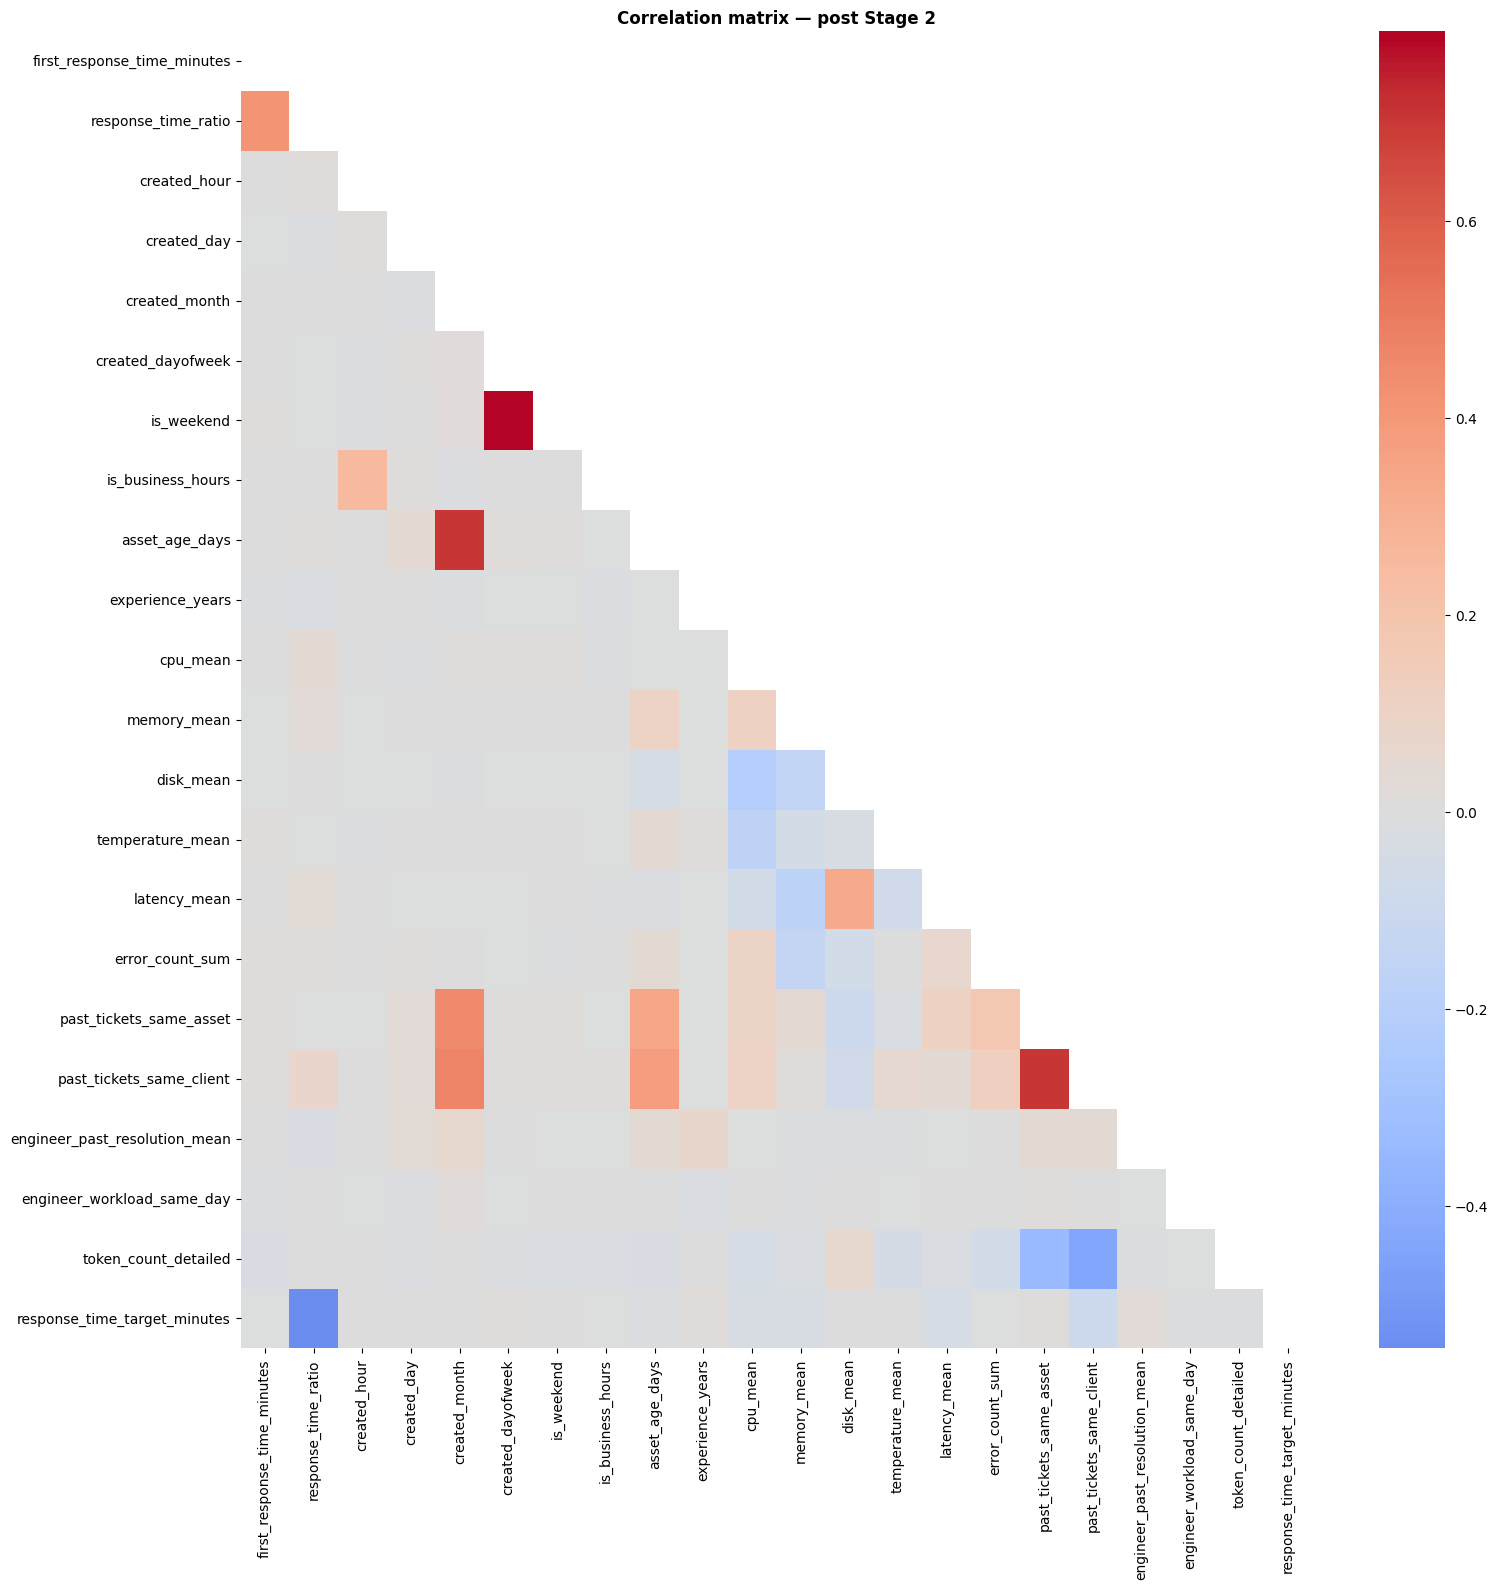

In [7]:
# =========================
# 3B. Stage 2 — Correlation filter
# =========================
# Remove one of any pair of features where |Pearson r| > 0.85.
# High correlation = multicollinearity = redundant information.
# Keeping both can inflate importance scores without adding signal.

X_vt = train_df_fs[Active_vt].fillna(0)
corr = X_vt.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.85
to_drop_corr  = [c for c in upper.columns if any(upper[c] > CORR_THRESHOLD)]
Active_corr = [c for c in Active_vt if c not in to_drop_corr]

print(f"Stage 2 — Correlation filter  (threshold |r| > {CORR_THRESHOLD})")
print(f"  Removed  : {len(to_drop_corr)}")
for col in to_drop_corr:
    partner = corr[col].drop(col).idxmax()
    print(f"    - {col:40s}  |r|={corr.loc[col,partner]:.3f} with {partner}")
print(f"  Active : {len(Active_corr)}")

# Correlation heatmap of surviving features
if Active_corr:
    fig, ax = plt.subplots(figsize=(min(len(Active_corr)*0.7+2,16), min(len(Active_corr)*0.7+2,16)))
    sns.heatmap(train_df_fs[Active_corr].fillna(0).corr(), annot=len(Active_corr)<=12,
                fmt=".2f", cmap="coolwarm", center=0, ax=ax,
                mask=np.triu(np.ones((len(Active_corr),len(Active_corr)),dtype=bool)))
    ax.set_title("Correlation matrix — post Stage 2", fontweight="bold")
    plt.tight_layout(); plt.savefig(PLOT_DIR/"fs_stage2_correlation.png",dpi=150,bbox_inches="tight")
    plt.show()


In [8]:
# =========================
# 3C. Stage 3 — Chi-squared test
# =========================
# Replaces Kaplan-Meier from the survival model.
# KM tests whether survival curves differ between groups.
# Chi-squared tests whether a feature's distribution is
# statistically associated with the class label.
# Keep features where p < 0.05 for at least one target.

_BASE_CATS = [c for c in [
    "ticket_channel","ticket_status","issue_type","ticket_category",
    "ticket_priority","device_type","manufacturer","model_number",
    "criticality_level","industry_sector","region","service_tier",
    "specialization","support_level","shift_type",
] if c in train_df_fs.columns]

cat_cols_for_fs = [c for c in _BASE_CATS
                   if c not in ["ticket_category","issue_type","ticket_priority"]]

X_cat_enc = train_df_fs[cat_cols_for_fs].copy()
for col in X_cat_enc.columns:
    X_cat_enc[col] = LabelEncoder().fit_transform(
        X_cat_enc[col].fillna("unknown").astype(str))

targets_chi2 = {
    "ticket_category": LabelEncoder().fit_transform(train_df_fs["ticket_category"].fillna("unknown")),
    "issue_type":      LabelEncoder().fit_transform(train_df_fs["issue_type"].fillna("unknown")),
    "ticket_priority": LabelEncoder().fit_transform(train_df_fs["ticket_priority"].fillna("unknown")),
}

chi2_results = {}
for tname, y_t in targets_chi2.items():
    scores, pvals = chi2(X_cat_enc, y_t)
    chi2_results[tname] = dict(zip(cat_cols_for_fs,
        [{"chi2":round(float(s),3),"p":round(float(p),4)} for s,p in zip(scores,pvals)]))

chi2_rows = [{"feature":col,
              **{f"p_{t}": chi2_results[t][col]["p"] for t in targets_chi2},
              "significant": any(chi2_results[t][col]["p"]<0.05 for t in targets_chi2)}
             for col in cat_cols_for_fs]
chi2_df = pd.DataFrame(chi2_rows).sort_values("significant",ascending=False)
sig_features_chi2 = chi2_df[chi2_df["significant"]]["feature"].tolist()

print(f"Stage 3 — Chi-squared  (α=0.05)")
print(f"  Tested       : {len(cat_cols_for_fs)}")
print(f"  Significant  : {len(sig_features_chi2)}")
display(chi2_df.reset_index(drop=True))


Stage 3 — Chi-squared  (α=0.05)
  Tested       : 12
  Significant  : 1


,feature,p_ticket_category,p_issue_type,p_ticket_priority,significant
0,region,0.0087,0.1778,0.0094,True
1,ticket_channel,0.6740,0.9684,0.9205,False
2,ticket_status,0.9977,0.1971,0.1994,False
3,device_type,0.7408,0.2592,0.5290,False
4,manufacturer,0.1987,0.6929,0.5536,False
5,model_number,0.0575,0.9104,0.6553,False
6,criticality_level,0.9379,0.9072,0.2412,False
7,industry_sector,0.8149,0.9074,0.3234,False
8,service_tier,0.3218,0.2984,0.7858,False
9,specialization,0.4419,0.1664,0.8702,False


In [9]:
# =========================
# 3D. Stage 4 — Mutual Information
# =========================
# Mutual Information (MI) measures how much knowing a feature reduces
# uncertainty about the class label. MI is model-free and works for
# both numeric and categorical features.
# Keep features where MI > 0 (carries any information about the target).
# Cox tests hazard ratios — does the feature change rate of event occurrence?
# Mutual Information (MI) measures how much knowing a feature reduces
# uncertainty about the class label. MI is model-free and works for
# both numeric and categorical features.
# Keep features where MI > 0 (carries any information about the target).

sla_num = pd.to_numeric(train_df_fs["sla_breach_flag"],errors="coerce").fillna(0).astype(int)
mi_targets = {
    "ticket_category": LabelEncoder().fit_transform(train_df_fs["ticket_category"].fillna("unknown")),
    "issue_type":      LabelEncoder().fit_transform(train_df_fs["issue_type"].fillna("unknown")),
    "ticket_priority": LabelEncoder().fit_transform(train_df_fs["ticket_priority"].fillna("unknown")),
    "sla_breach_flag": sla_num,
}

X_mi = train_df_fs[Active_corr].fillna(0)
mi_results = {}
for tname, y_t in mi_targets.items():
    mi_results[tname] = dict(zip(Active_corr,
        mutual_info_classif(X_mi, y_t, random_state=42, n_neighbors=5).round(6)))

mi_df = pd.DataFrame([{"feature":col,
                        **{f"MI_{t}": mi_results[t][col] for t in mi_targets},
                        "MI_avg": np.mean([mi_results[t][col] for t in mi_targets])}
                       for col in Active_corr]).sort_values("MI_avg",ascending=False)

Active_mi = mi_df[mi_df["MI_avg"] > 0]["feature"].tolist()

print(f"Stage 4 — Mutual Information  (threshold MI > 0)")
print(f"  Active: {len(Active_mi)}")
display(mi_df)


Stage 4 — Mutual Information  (threshold MI > 0)
  Active: 20


,feature,MI_ticket_category,MI_issue_type,MI_ticket_priority,MI_sla_breach_flag,MI_avg
21,response_time_target_minutes,0.000000,0.000000,0.651949,0.000000,0.162987
1,response_time_ratio,0.000000,0.000000,0.440182,0.003309,0.110873
20,token_count_detailed,0.003848,0.044342,0.000000,0.004329,0.013130
9,experience_years,0.000000,0.007445,0.002244,0.006348,0.004009
2,created_hour,0.002861,0.002287,0.006337,0.001900,0.003346
4,created_month,0.000492,0.005712,0.005808,0.000000,0.003003
14,latency_mean,0.004625,0.004582,0.001263,0.000000,0.002618
8,asset_age_days,0.003781,0.004550,0.000000,0.001998,0.002582
17,past_tickets_same_client,0.003634,0.002665,0.003916,0.000000,0.002554
6,is_weekend,0.002357,0.002936,0.004007,0.000638,0.002484


In [10]:
# =========================
# 3E. Stage 5 — SelectKBest on TF-IDF + RF permutation
# =========================
# This stage has no equivalent in the survival model — no text fields there.
#
# Part A: SelectKBest chi-squared on TF-IDF
#   Finds the 50 most discriminative n-grams from ticket_detailed_description
#   per classification target.
#
# Part B: Random Forest permutation importance
#   Trains a quick RF on surviving structured features.

# Part A — TF-IDF token selection
TEXT_COL_NLP = "nlp_text_detailed"   # ONLY ticket_detailed_description

tfidf_sel = TfidfVectorizer(max_features=500, ngram_range=(1,2),
                             stop_words="english", min_df=3)
X_text_full = tfidf_sel.fit_transform(
    train_df_fs[TEXT_COL_NLP].fillna("unknown").astype(str))

token_selection = {}
for tname, y_t in mi_targets.items():
    sel = SelectKBest(chi2, k=min(50, X_text_full.shape[1]))
    X_sc = MinMaxScaler().fit_transform(X_text_full.toarray())
    sel.fit(X_sc, y_t)
    top_idx = sel.scores_.argsort()[::-1][:20]
    token_selection[tname] = [(tfidf_sel.get_feature_names_out()[i],
                                round(float(sel.scores_[i]),2)) for i in top_idx]
    print(f"  Top 10 tokens — {tname}:")
    for tok,sc in token_selection[tname][:10]: print(f"    {tok:35s}  chi2={sc:.2f}")
    print()

# Part B — RF permutation importance
print("RF permutation importance (ticket_category)...")
cat_enc = pd.get_dummies(train_df_fs[[c for c in sig_features_chi2 if c in train_df_fs.columns][:5]].fillna("unknown"),drop_first=True)
num_df_rf = train_df_fs[Active_mi[:8]].fillna(0) if Active_mi else pd.DataFrame(index=train_df_fs.index)
X_rf = pd.concat([num_df_rf, cat_enc],axis=1).fillna(0)
if len(X_rf.columns) > 0:
    y_cat = LabelEncoder().fit_transform(train_df_fs["ticket_category"].fillna("unknown"))
    rf_q = RandomForestClassifier(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1)
    rf_q.fit(X_rf, y_cat)
    perm = permutation_importance(rf_q,X_rf,y_cat,n_repeats=5,random_state=42,n_jobs=-1)
    perm_df = pd.DataFrame({"feature":X_rf.columns,"importance":perm.importances_mean}
                           ).sort_values("importance",ascending=False)
    display(perm_df.head(15))


  Top 10 tokens — ticket_category:
    network                              chi2=1531.37
    power self                           chi2=1133.30
    test post                            chi2=1122.76
    switch                               chi2=1100.56
    sector                               chi2=954.70
    reporting                            chi2=936.83
    disk wait                            chi2=890.33
    self test                            chi2=873.20
    users                                chi2=835.83
    test                                 chi2=817.23

  Top 10 tokens — issue_type:
    experienced                          chi2=3279.89
    disk wait                            chi2=2763.37
    experienced unexpected               chi2=2513.85
    network latency                      chi2=2357.63
    network congestion                   chi2=2321.14
    switch experienced                   chi2=2207.80
    power self                           chi2=2168.62
    test post         

,feature,importance
1,response_time_ratio,0.081974
2,token_count_detailed,0.080949
7,asset_age_days,0.080256
4,created_hour,0.076379
6,latency_mean,0.070757
5,created_month,0.055196
3,experience_years,0.049147
0,response_time_target_minutes,0.028937
9,region_US,0.024594
8,region_India,0.017426


In [11]:
# =========================
# 3F. Feature selection funnel summary
# =========================
# Terminal output format showing feature counts at each stage.

print("=" * 60)
print("  FEATURE SELECTION FUNNEL — TICKET ANALYTICS")
print("=" * 60)
print(f"  Initial numeric features          : {len(_BASE_NUMS)}")
print(f"  After variance filter  (Stage 1)  : {len(Active_vt)}  (removed {len(removed_by_vt)})")
print(f"    Logic: remove features where >95% of rows share the same value")
print()
print(f"  After correlation filter (Stage 2) : {len(Active_corr)}  (removed {len(to_drop_corr)})")
print(f"    Logic: remove one of any pair with |r| > 0.85")
print()
print(f"  Categorical tested (Stage 3)       : {len(cat_cols_for_fs)}")
print(f"  Significant by chi-sq (p<0.05)     : {len(sig_features_chi2)}")
print(f"    Logic: keep features with significant association with target class")
print()
print(f"  After MI filter (Stage 4)          : {len(Active_mi)}")
print(f"    Logic: keep features carrying any information about the target (MI>0)")
print()
print(f"  TF-IDF tokens evaluated (Stage 5)  : {X_text_full.shape[1]}")
print(f"    Logic: SelectKBest chi-sq keeps top 50 discriminative n-grams per target")
print()
print("=" * 60)
print("  Current data note: near-uniform breach flag (~40%) means structured")
print("  features show weak signal. Pipeline is ready for real operational data.")
print("=" * 60)

SELECTED_CATS = sig_features_chi2
SELECTED_NUMS = Active_mi

import pickle as _pk
selection_results = {"variance_removed":removed_by_vt,"correlation_removed":to_drop_corr,
                     "chi2_significant":sig_features_chi2,"mi_Active":Active_mi,
                     "token_selection":token_selection,
                     "selected_cats":SELECTED_CATS,"selected_nums":SELECTED_NUMS}
with open(PKL_DIR/"feature_selection_results.pkl","wb") as _f: _pk.dump(selection_results,_f)
print("\n✅  feature_selection_results.pkl saved")


  FEATURE SELECTION FUNNEL — TICKET ANALYTICS
  Initial numeric features          : 30
  After variance filter  (Stage 1)  : 26  (removed 4)
    Logic: remove features where >95% of rows share the same value

  After correlation filter (Stage 2) : 22  (removed 4)
    Logic: remove one of any pair with |r| > 0.85

  Categorical tested (Stage 3)       : 12
  Significant by chi-sq (p<0.05)     : 1
    Logic: keep features with significant association with target class

  After MI filter (Stage 4)          : 20
    Logic: keep features carrying any information about the target (MI>0)

  TF-IDF tokens evaluated (Stage 5)  : 500
    Logic: SelectKBest chi-sq keeps top 50 discriminative n-grams per target

  Current data note: near-uniform breach flag (~40%) means structured
  features show weak signal. Pipeline is ready for real operational data.

✅  feature_selection_results.pkl saved


# 4. PREPROCESSING

## Objective
Prepare the data for machine learning while preventing leakage.

## Core rules
- Text is vectorized with TF-IDF on `ticket_detailed_description` only.
- Categorical variables use mode imputation and one-hot encoding.
- Numeric variables use median imputation and standard scaling.
- Train/test split is **time-based**: 2023–2024 train, 2025 test.

## Leakage rule
Exclude post-resolution variables when the target cannot know them at
ticket-creation time: `resolution_time_minutes`, `resolution_notes`,
`sla_breach_flag`, `escalation_flag`, `ticket_reopen_flag`.

## Dynamic feature pools
`dynamic_feature_pools()` from schema_utils automatically adjusts
the feature lists when source data gains or loses columns.


In [12]:
# =========================
# 4A. Feature pools and train/test split
# =========================
# IMPORTANT: TEXT_COL_NLP (ticket_detailed_description) is the ONLY
# text column used for NLP classification and TF-IDF vectorisation.
# ticket_description is excluded from all model features — display metadata only.

TEXT_COL_NLP = "nlp_text_detailed"

POST_EVENT_COLS = ["sla_breach_flag","escalation_flag","ticket_reopen_flag",
                   "resolution_notes","invalid_close_before_create"]

_BASE_CATS_FULL = [c for c in [
    "ticket_channel","ticket_status","issue_type","ticket_category","ticket_priority",
    "device_type","manufacturer","model_number","criticality_level",
    "industry_sector","region","service_tier","specialization","support_level","shift_type",
] if c in base.columns]

_BASE_NUMS_FULL = [c for c in [
    "first_response_time_minutes","response_time_ratio",
    "created_hour","created_day","created_month","created_dayofweek",
    "is_weekend","is_business_hours","asset_age_days","warranty_active",
    "experience_years","cpu_mean","memory_mean","disk_mean",
    "temperature_mean","latency_mean","packet_loss_mean","error_count_sum","failure_flag_mean",
    "past_tickets_same_asset","past_tickets_same_client","prior_sla_breaches_same_asset",
    "engineer_past_resolution_mean","engineer_past_sla_success_rate","engineer_workload_same_day",
    "token_count_detailed","detailed_desc_missing","is_repeated_text",
    "response_time_target_minutes","resolution_time_target_minutes",
] if c in base.columns]

# Apply dynamic pool builder — auto-classifies new columns from schema drift
all_new_cols = list({c for diff in schema_diffs.values() for c in diff.get("added",[])})
combined_diff = {"added": all_new_cols}

if dynamic_feature_pools is not None:
    COMMON_CATS, COMMON_NUMS, NEW_FLAGS = dynamic_feature_pools(
        df=base, schema_diff=combined_diff,
        existing_cats=SELECTED_CATS if SELECTED_CATS else _BASE_CATS_FULL,
        existing_nums=SELECTED_NUMS if SELECTED_NUMS else _BASE_NUMS_FULL,
        verbose=True)
else:
    COMMON_CATS = [c for c in _BASE_CATS_FULL if c in base.columns]
    COMMON_NUMS = [c for c in _BASE_NUMS_FULL if c in base.columns]
    NEW_FLAGS   = []

BASE_DROP = ["year","year_ticket_id","ticket_id","ticket_created_timestamp",
             "ticket_close_timestamp","contract_start_date","contract_end_date",
             "installation_date","warranty_expiry_date","telemetry_year","timestamp",
             "engineer_name","client_name","ticket_description","combined_text"]

# Time-based split
train_df = base[base["year"].isin([2023, 2024])].copy()
test_df  = base[base["year"] == 2025].copy()

print(f"Train : {len(train_df):,} rows (2023–2024)")
print(f"Test  : {len(test_df):,} rows (2025)")
print(f"Feature pools: {len(COMMON_CATS)} categorical + {len(COMMON_NUMS)} numeric")



  ── Feature pool update ──────────────────────────────────────
  New columns auto-classified:
    ⚠️ REVIEW year                                → numeric (inferred)
  Final pools: 1 categorical, 21 numeric
  ─────────────────────────────────────────────────────────────

Train : 15,012 rows (2023–2024)
Test  : 7,479 rows (2025)
Feature pools: 1 categorical + 21 numeric


In [13]:
# =========================
# 4B. Preprocessor builder
# =========================
# Builds a ColumnTransformer with three branches:
#   num  → median imputation + StandardScaler
#   cat  → mode imputation + OneHotEncoder (handle_unknown=ignore)
#   txt  → TF-IDF on nlp_text_detailed (ticket_detailed_description only)

# =========================
# Text flattener — defined at module level so it can be pickled
# =========================
# Lambda functions inside FunctionTransformer cannot be pickled.
# This named function is equivalent but pickle-safe.
def flatten_text_column(x):
    """
    Flatten a text column to a plain string Series.
    Fills nulls with 'unknown'. Must be defined at module level
    (not inside another function) for pickle compatibility.
    """
    import pandas as pd
    if hasattr(x, "fillna"):
        return x.fillna("unknown").astype(str)
    return pd.Series(x).fillna("unknown").astype(str)


def make_preprocessor(cats, nums, txt=None):
    transformers = []
    if nums:
        transformers.append(("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler())
        ]), nums))
    if cats:
        transformers.append(("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cats))
    if txt:
        transformers.append(("txt", Pipeline([
            # Use named function — NOT a lambda — for pickle compatibility
            ("flat",  FunctionTransformer(flatten_text_column, validate=False)),
            ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1, 2),
                                       stop_words="english"))
        ]), txt))
    return ColumnTransformer(transformers, remainder="drop")

def prepare_xy(tr, te, target, leakage=[]):
    drop = set(BASE_DROP + leakage + [target])
    Xtr = tr.drop(columns=[c for c in drop if c in tr.columns], errors="ignore")
    Xte = te.drop(columns=[c for c in drop if c in te.columns], errors="ignore")
    ytr, yte = tr[target], te[target]
    mtr, mte = ytr.notna(), yte.notna()
    return Xtr[mtr], Xte[mte], ytr[mtr], yte[mte]

def infer_features(X, target=None):
    cats = [c for c in COMMON_CATS if c in X.columns]
    nums = [c for c in COMMON_NUMS if c in X.columns]
    txt  = TEXT_COL_NLP if TEXT_COL_NLP in X.columns else None
    return cats, nums, txt

def get_feat_names(ct):
    names = []
    for n, tfm, cols in ct.transformers_:
        if n == "remainder": continue
        if n == "num": names.extend(cols)
        elif n == "cat": names.extend(tfm.named_steps["ohe"].get_feature_names_out(cols))
        elif n == "txt": names.extend([f"txt__{t}" for t in tfm.named_steps["tfidf"].get_feature_names_out()])
    return names

# 5. MODEL TRAINING & EVALUATION

## Objective
Build and evaluate the predictive models for the ticket intelligence engine.

## Models trained

### Classification targets
- **ticket_category** — Hardware / Network (binary)
- **issue_type** — Access / Crash / Failure / Slow (4-class)
- **ticket_priority** — P1 / P2 / P3 / P4 (4-class)

### Regression target
- **resolution_time_minutes** — predicted resolution time in minutes

## Model families
Logistic Regression, Random Forest, XGBoost (where available)  
Linear Regression, Random Forest Regressor

## Train/test split
Time-based: **2023–2024 train, 2025 test** — simulates real deployment
where the model is trained on historical data and scored on new tickets.

## NLP modeling note
`ticket_detailed_description` (via `nlp_text_detailed`) is the primary NLP
text field. It provides richer problem context than the short `ticket_description`.
`ticket_description` is excluded from all model features.


In [16]:
# =========================
# 5A. Target configs and training loop
# =========================
# Note: SLA breach is handled in the separate SLA breach notebook.
# Its outputs feed into Module 3 via sla_breach_scores.pkl.

TARGETS = {
    "ticket_category":         {"type":"classification",
                                "models":["logistic_regression","random_forest"],
                                "leakage":["resolution_time_minutes"]+POST_EVENT_COLS},
    "issue_type":              {"type":"classification",
                                "models":["logistic_regression"]+
                                (["xgboost"] if XGB_AVAILABLE else []),
                                "leakage":["resolution_time_minutes"]+POST_EVENT_COLS},
    "ticket_priority":         {"type":"classification",
                                "models":["logistic_regression","random_forest"],
                                "leakage":["resolution_time_minutes"]+POST_EVENT_COLS},
    "resolution_time_minutes": {"type":"regression",
                                "models":["linear_regression","random_forest_regressor"],
                                "leakage":POST_EVENT_COLS},
}

def eval_clf(pipe, Xte, yte):
    p = pipe.predict(Xte)
    res = {"accuracy":accuracy_score(yte,p),
           "f1_weighted":f1_score(yte,p,average="weighted",zero_division=0)}
    if len(yte.unique())==2 and hasattr(pipe,"predict_proba"):
        res["roc_auc"] = roc_auc_score(yte, pipe.predict_proba(Xte)[:,1])
    return res

def eval_reg(pipe, Xte, yte):
    p = pipe.predict(Xte)
    return {"mae":mean_absolute_error(yte,p),
            "rmse":mean_squared_error(yte,p)**0.5,
            "r2":r2_score(yte,p)}

trained_models = {}; label_encoders = {}; model_result_rows = []

for target, cfg in TARGETS.items():
    print(f"\n{'─'*55}\nTarget: {target}")
    Xtr,Xte,ytr,yte = prepare_xy(train_df,test_df,target,cfg["leakage"])
    if len(ytr)==0 or len(yte)==0: print("  Skipping — empty"); continue
    cats,nums,txt = infer_features(Xtr, target)

    for mname in cfg["models"]:
        le=None; ytr_f,yte_e = ytr.copy(),yte.copy()
        if cfg["type"]=="classification":
            if mname=="logistic_regression":
                clf=LogisticRegression(max_iter=1000,random_state=RANDOM_STATE)
            elif mname=="random_forest":
                clf=RandomForestClassifier(n_estimators=200,class_weight="balanced",
                                           random_state=RANDOM_STATE,n_jobs=-1)
            elif mname=="xgboost":
                le=LabelEncoder()
                ytr_f=pd.Series(le.fit_transform(ytr),index=ytr.index)
                yte_e=pd.Series(le.transform(yte),index=yte.index)
                n_cls=int(ytr_f.nunique())
                clf=XGBClassifier(
                    objective="binary:logistic" if n_cls==2 else "multi:softprob",
                    num_class=None if n_cls==2 else n_cls,
                    eval_metric="logloss" if n_cls==2 else "mlogloss",
                    n_estimators=200,max_depth=6,learning_rate=0.05,
                    random_state=RANDOM_STATE,n_jobs=-1)
            else: continue
        else:
            clf = (LinearRegression() if mname=="linear_regression"
                   else RandomForestRegressor(n_estimators=200,random_state=RANDOM_STATE,n_jobs=-1))

        pipe = Pipeline([("preprocessor",make_preprocessor(cats,nums,txt)),("model",clf)])
        try: pipe.fit(Xtr, ytr_f)
        except Exception as e: print(f"  ⚠️  {mname}: {e}"); continue

        key=(target,mname)
        trained_models[key]={"pipeline":pipe,"X_train":Xtr,"X_test":Xte,
                              "y_train":ytr,"y_test":yte,"y_train_fit":ytr_f,"y_test_eval":yte_e}
        if le: label_encoders[key]=le

        try:
            if cfg["type"]=="classification":
                m=eval_clf(pipe,Xte,yte_e)
                row={"target":target,"model":mname,"type":"classification",
                     "accuracy":m["accuracy"],"f1_weighted":m["f1_weighted"],
                     "roc_auc":m.get("roc_auc",np.nan),"rmse":np.nan,"r2":np.nan}
            else:
                m=eval_reg(pipe,Xte,yte_e)
                row={"target":target,"model":mname,"type":"regression",
                     "accuracy":np.nan,"f1_weighted":np.nan,"roc_auc":np.nan,
                     "rmse":m["rmse"],"r2":m["r2"]}
            model_result_rows.append(row)
            print(f"  ✅  {mname:28s} → {row}")
        except Exception as e: print(f"  ⚠️  eval: {e}")

model_results = pd.DataFrame(model_result_rows)
display(model_results)



───────────────────────────────────────────────────────
Target: ticket_category
  ✅  logistic_regression          → {'target': 'ticket_category', 'model': 'logistic_regression', 'type': 'classification', 'accuracy': 0.8423447537473233, 'f1_weighted': 0.8420514843452038, 'roc_auc': np.float64(0.9505233677803188), 'rmse': nan, 'r2': nan}
  ✅  random_forest                → {'target': 'ticket_category', 'model': 'random_forest', 'type': 'classification', 'accuracy': 0.8403372591006424, 'f1_weighted': 0.8401654689433924, 'roc_auc': np.float64(0.9484981028365747), 'rmse': nan, 'r2': nan}

───────────────────────────────────────────────────────
Target: issue_type
  ✅  logistic_regression          → {'target': 'issue_type', 'model': 'logistic_regression', 'type': 'classification', 'accuracy': 0.7183946488294315, 'f1_weighted': 0.728040980977653, 'roc_auc': nan, 'rmse': nan, 'r2': nan}
  ✅  xgboost                      → {'target': 'issue_type', 'model': 'xgboost', 'type': 'classification', '

,target,model,type,accuracy,f1_weighted,roc_auc,rmse,r2
0,ticket_category,logistic_regression,classification,0.842345,0.842051,0.950523,NaN,NaN
1,ticket_category,random_forest,classification,0.840337,0.840165,0.948498,NaN,NaN
2,issue_type,logistic_regression,classification,0.718395,0.728041,NaN,NaN,NaN
3,issue_type,xgboost,classification,0.729097,0.727908,NaN,NaN,NaN
4,ticket_priority,logistic_regression,classification,0.478918,0.459030,NaN,NaN,NaN
5,ticket_priority,random_forest,classification,0.540624,0.509316,NaN,NaN,NaN
6,resolution_time_minutes,linear_regression,regression,NaN,NaN,NaN,525.777036,0.829041
7,resolution_time_minutes,random_forest_regressor,regression,NaN,NaN,NaN,513.364460,0.837018


In [17]:
# =========================
# 5B. Best model selection
# =========================
# Classification: rank by f1_weighted (primary) + roc_auc (tiebreaker).
# Regression: rank by RMSE (lower is better).

def pick_best(df, target):
    sub = df[df["target"]==target]
    if sub.empty: return None
    if sub["type"].iloc[0]=="classification":
        sub = sub.copy()
        sub["score"] = sub["f1_weighted"].fillna(-1) + sub["roc_auc"].fillna(0)*0.01
        return sub.sort_values("score",ascending=False).iloc[0]
    return sub.sort_values("rmse").iloc[0]

best_models = pd.DataFrame([pick_best(model_results,t) for t in TARGETS]).dropna(subset=["target"])
display(best_models[["target","model","f1_weighted","roc_auc","rmse","r2"]])

def get_best_key(target):
    row = best_models[best_models["target"]==target]
    if row.empty: return None
    r = row.iloc[0]; return (r["target"],r["model"])

def decode_pred(key, pred):
    le = label_encoders.get(key)
    return le.inverse_transform(np.array(pred).astype(int))[0] if le else pred[0]


,target,model,f1_weighted,roc_auc,rmse,r2
0,ticket_category,logistic_regression,0.842051,0.950523,NaN,NaN
2,issue_type,logistic_regression,0.728041,NaN,NaN,NaN
5,ticket_priority,random_forest,0.509316,NaN,NaN,NaN
7,resolution_time_minutes,random_forest_regressor,NaN,NaN,513.36446,0.837018


# 6. RECOMMENDATION ENGINE

## Objective
Retrieve similar historical tickets and recommend likely resolution actions.

## Design

### Stage 1: Similar ticket retrieval
Uses **TF-IDF + cosine similarity** on `ticket_detailed_description`
(via `nlp_text_detailed`) combined with `issue_type` and `device_type`.

### Stage 2: Rule-based ranking
Re-ranks the top-K similar tickets by a composite score:
- similarity score (0.60 weight),
- same issue type bonus (0.15),
- same asset/device type bonus (0.10),
- faster historical resolution (0.10),
- fewer historical reopens (0.05).

## Outputs per ticket
- Top 5 similar historical tickets
- Suggested resolution (mode of top-5 resolution notes)
- Recommended engineer group (mode of top-5 specializations)
- Expected resolution time (mean of top-5 resolution times)


In [18]:
# =========================
# 6A. Fit TF-IDF vectoriser
# =========================
# Trained on reco_base["reco_text"] which was built from nlp_text_detailed
# (ticket_detailed_description) only — not ticket_description.

reco_vectorizer = TfidfVectorizer(max_features=700, ngram_range=(1,2), stop_words="english")
reco_matrix     = reco_vectorizer.fit_transform(reco_base["reco_text"])

print(f"TF-IDF trained on nlp_text_detailed (ticket_detailed_description) only.")
print(f"Recommendation library : {len(reco_base):,} tickets")
print(f"TF-IDF matrix shape    : {reco_matrix.shape}")

def recommend_similar(query_nlp_text, issue_type=None, asset_type=None, top_k=5):
    """
    Retrieve and rank similar historical tickets.
    query_nlp_text must come from ticket_detailed_description only.
    """
    q = " | ".join([str(x) if pd.notna(x) else "unknown"
                    for x in [query_nlp_text, issue_type, asset_type]])
    q_vec = reco_vectorizer.transform([q])
    sims  = cosine_similarity(q_vec, reco_matrix).flatten()
    recs  = reco_base.copy(); recs["similarity_score"] = sims
    same_issue  = (recs["issue_type"].astype(str)==str(issue_type)).astype(int) if issue_type else 0
    same_asset  = (recs["device_type"].astype(str)==str(asset_type)).astype(int) if asset_type else 0
    res_time    = recs["resolution_time_minutes"].fillna(recs["resolution_time_minutes"].median())
    reopen      = recs.get("ticket_reopen_flag_num", pd.Series(0,index=recs.index)).fillna(0)
    recs["ranking_score"] = (recs["similarity_score"]*0.60 + same_issue*0.15 +
                             same_asset*0.10 + (1/(1+res_time))*0.10 + (1/(1+reopen))*0.05)
    cols = [c for c in ["year_ticket_id","ticket_category","issue_type","ticket_priority",
                        "device_type","engineer_id","specialization","resolution_time_minutes",
                        "resolution_notes","similarity_score","ranking_score"] if c in recs.columns]
    return recs.sort_values(["ranking_score","similarity_score"],ascending=False)[cols].head(top_k)

def summarize_recs(recs_df):
    if recs_df.empty:
        return {"suggested_resolution":None,"recommended_engineer_group":None,"expected_resolution_time":None}
    rm = recs_df["resolution_notes"].dropna().astype(str).mode()
    sm = recs_df["specialization"].dropna().astype(str).mode()
    return {"suggested_resolution": rm.iloc[0] if len(rm) else None,
            "recommended_engineer_group": sm.iloc[0] if len(sm) else None,
            "expected_resolution_time": round(float(recs_df["resolution_time_minutes"].dropna().mean()),2)}

# Demo on first valid test ticket
demo = test_df[test_df["nlp_text_detailed"].notna() & test_df["issue_type"].notna()].iloc[0]
demo_recs = recommend_similar(demo["nlp_text_detailed"], demo["issue_type"], demo.get("device_type"))
display(demo_recs)
display(pd.DataFrame([summarize_recs(demo_recs)]))


TF-IDF trained on nlp_text_detailed (ticket_detailed_description) only.
Recommendation library : 15,363 tickets
TF-IDF matrix shape    : (15363, 700)


,year_ticket_id,ticket_category,issue_type,ticket_priority,device_type,engineer_id,specialization,resolution_time_minutes,resolution_notes,similarity_score,ranking_score
16617,2025_T0004606,Network,Crash,P1,Server,E019,Server,251.27,Replaced PSU.,1.000000,0.875396
18000,2025_T0005989,Network,Crash,P2,Server,E007,Network,712.27,Replaced PSU.,0.728420,0.737192
5082,2023_T0005083,Network,Crash,P4,Server,E014,Server,3179.55,Replaced PSU.,0.744296,0.721609
19081,2025_T0007070,Network,Crash,P4,Server,E016,Network,3042.38,Replaced PSU.,0.697135,0.693314
11606,2024_T0002181,Network,Crash,P4,Server,E009,Network,3436.13,Replaced PSU.,0.648032,0.688848


,suggested_resolution,recommended_engineer_group,expected_resolution_time
0,Replaced PSU.,Network,2124.32


# 7. PREDICT ON OPEN SYNTHETIC TICKETS

## Objective
Apply the trained models to all open (non-resolved) tickets in
`ticket_assignment_synthetic.xlsx` and save predictions as
`open_ticket_predictions.pkl` for use in Module 3.

## Why
Module 3 (Engineer Assignment) needs model predictions — category,
priority, issue type, predicted resolution time, and recommended
engineer group — for every open ticket before it can run the
assignment engine and generate suggestions.


In [19]:
# =========================
# 7A. Score open synthetic tickets
# =========================
if not SYNTH_FILE.exists():
    print(f"⚠️  {SYNTH_FILE} not found — skipping synthetic scoring")
    synth_scored = pd.DataFrame()
else:
    synth_ah = pd.read_excel(SYNTH_FILE, sheet_name="ticket_assignment_history")

    # Open tickets = is_current=True AND ticket_status is not Resolved AND resolved_at is null
    open_synth = synth_ah[
        (synth_ah["is_current"]==True) &
        (synth_ah["ticket_status"].str.upper().ne("RESOLVED")) &
        (synth_ah["resolved_at"].isna())
    ].copy()
    print(f"Open synthetic tickets: {len(open_synth)}")

    ENGINEERS_MASTER = {
        "E001":{"spec":"Network","exp":6},"E002":{"spec":"Network","exp":7},
        "E003":{"spec":"Network","exp":1},"E004":{"spec":"Server","exp":6},
        "E005":{"spec":"Network","exp":6},"E006":{"spec":"Network","exp":4},
        "E007":{"spec":"Network","exp":6},"E008":{"spec":"Server","exp":10},
        "E009":{"spec":"Network","exp":4},"E010":{"spec":"Network","exp":3},
        "E011":{"spec":"Server","exp":1},"E012":{"spec":"Network","exp":6},
        "E013":{"spec":"Server","exp":4},"E014":{"spec":"Server","exp":3},
        "E015":{"spec":"Network","exp":7},"E016":{"spec":"Network","exp":8},
        "E017":{"spec":"Network","exp":4},"E018":{"spec":"Server","exp":6},
        "E019":{"spec":"Server","exp":4},"E020":{"spec":"Network","exp":1},
    }

    synth_scored_rows = []
    for _, row in open_synth.iterrows():
        cat   = str(row.get("ticket_category","Network"))
        prio  = str(row.get("ticket_priority","P3"))
        issue = str(row.get("issue_type","Access"))
        eng   = str(row.get("employee_id","E001"))

        # Find a matching historical ticket to populate the full feature set
        match = base[(base["ticket_category"]==cat)&(base["ticket_priority"]==prio)
                     &(base["issue_type"]==issue)].head(1)
        if match.empty: match = base[base["ticket_priority"]==prio].head(1)
        if match.empty: continue

        tdf = match.copy()
        if eng in ENGINEERS_MASTER:
            tdf["engineer_id"]      = eng
            tdf["specialization"]   = ENGINEERS_MASTER[eng]["spec"]
            tdf["experience_years"] = ENGINEERS_MASTER[eng]["exp"]

        preds = {"assignment_id": row["assignment_id"], "ticket_id": row["ticket_id"]}
        for target in ["ticket_category","issue_type","ticket_priority"]:
            key = get_best_key(target)
            if key and key in trained_models:
                try:
                    pred = trained_models[key]["pipeline"].predict(tdf)
                    preds[f"pred_{target}"] = decode_pred(key, pred)
                    if hasattr(trained_models[key]["pipeline"],"predict_proba"):
                        pr = trained_models[key]["pipeline"].predict_proba(tdf)
                        preds[f"conf_{target}"] = round(float(np.max(pr[0])),4)
                except: pass

        res_key = get_best_key("resolution_time_minutes")
        if res_key and res_key in trained_models:
            try:
                preds["pred_resolution_time"] = round(
                    float(trained_models[res_key]["pipeline"].predict(tdf)[0]),2)
            except: pass

        nlp_q = str(tdf["nlp_text_detailed"].iloc[0]) if "nlp_text_detailed" in tdf else "unknown"
        recs  = recommend_similar(nlp_q, issue, cat)
        rs    = summarize_recs(recs)
        preds["suggested_resolution"]  = rs.get("suggested_resolution")
        preds["recommended_eng_group"] = rs.get("recommended_engineer_group")
        preds["expected_res_time"]     = rs.get("expected_resolution_time")
        synth_scored_rows.append(preds)

    synth_scored = pd.DataFrame(synth_scored_rows)
    print(f"Scored {len(synth_scored)} open tickets")
    display(synth_scored)


Open synthetic tickets: 16
Scored 16 open tickets


,assignment_id,ticket_id,pred_ticket_category,conf_ticket_category,pred_issue_type,conf_issue_type,pred_ticket_priority,conf_ticket_priority,pred_resolution_time,suggested_resolution,recommended_eng_group,expected_res_time
0,13,T00041002,Network,0.9964,Slow,0.9905,P2,0.840,489.42,Optimized routing tables.,Server,1620.04
1,15,T00041003,Network,0.9843,Crash,0.9962,P1,0.900,207.33,Replaced PSU.,Network,859.96
2,18,T00041005,Network,0.9918,Access,0.9939,P2,0.735,408.52,Reset LDAP sync.,Network,1435.84
3,20,T00041006,Network,0.9988,Slow,0.9736,P3,0.715,1455.29,Optimized routing tables.,Network,1774.94
4,21,T00041007,Network,0.9965,Slow,0.9904,P2,0.835,488.94,Optimized routing tables.,Server,1620.04
5,22,T00041008,Network,0.9968,Access,0.9983,P3,0.790,1195.95,Reset LDAP sync.,Network,2593.07
6,23,T00041009,Network,0.9860,Failure,0.9405,P3,0.705,1375.01,Replaced faulty NIC and patched firmware.,Server,1702.21
7,25,T00041011,Network,0.9829,Access,0.7054,P4,0.825,2544.38,Replaced faulty NIC and patched firmware.,Network,1571.29
8,26,T00041012,Network,0.9926,Failure,0.5521,P2,0.815,431.76,Replaced faulty NIC and patched firmware.,Network,713.90
9,29,T00041014,Hardware,0.9932,Crash,0.9824,P3,0.815,1245.12,Cleaned cooling fans.,Network,2156.53


# 8. SAVE ALL MODEL OUTPUTS

## Objective
Persist all trained model artefacts and predictions to Google Drive.

## Files saved
All files go to `Drive/Innodatatics_Capstone/ticket_pkl_outputs/`


In [20]:
# =========================
# 8A. Save all pkl outputs
# =========================
save_pkl(base,                    "ticket_base.pkl")       # updated with engineered features
save_pkl(trained_models,          "trained_models.pkl")
save_pkl(model_results,           "model_results.pkl")
save_pkl(best_models,             "best_models.pkl")
save_pkl(label_encoders,          "label_encoders.pkl")
save_pkl(reco_vectorizer,         "reco_vectorizer.pkl")
save_pkl(reco_matrix,             "reco_matrix.pkl")
save_pkl(synth_scored,            "open_ticket_predictions.pkl")

print("\n✅  Module 2 complete.")
print(f"   All outputs saved to: {PKL_DIR}")
print("   Next step → open and run Ticket_03_Engineer_Assignment.ipynb")


  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/ticket_base.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/trained_models.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/model_results.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/best_models.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/label_encoders.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/reco_vectorizer.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/reco_matrix.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/open_ticket_predictions.pkl

✅  Module 2 complete.
   All outputs saved to: /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   Next step → open and run Ticket_03_Engineer_Assignment.ipynb
